**This notebook reproduces the results from section 5.1 of the paper "Multisensor Track-to-Track Association for Tracks with Dependent Errors" by Y. Bar-Shalom**

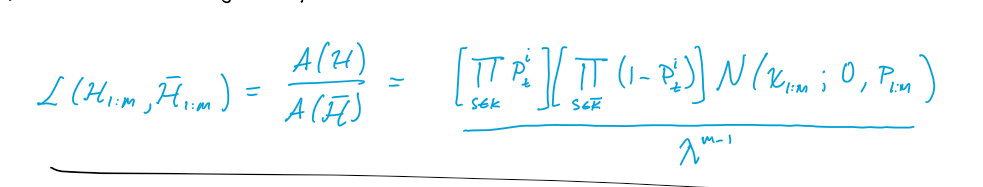

In [1]:
import numpy as np
from scipy.stats import multivariate_normal

import matplotlib.pyplot as plt
import seaborn as sns

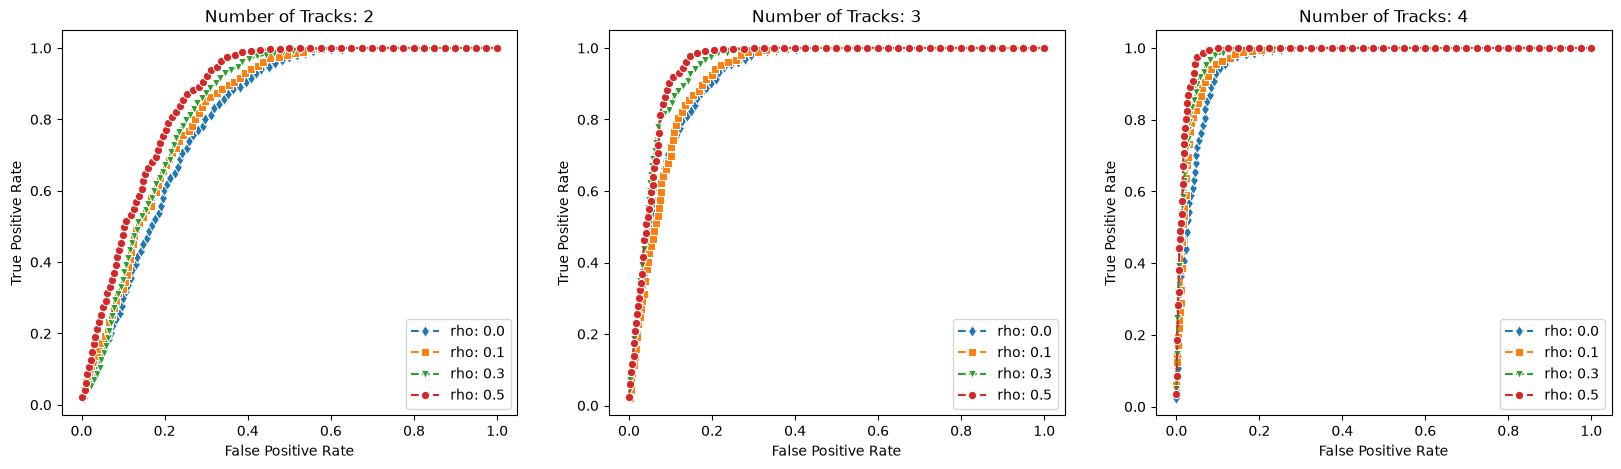

In [12]:
true_states = np.random.uniform(-5, 5, 1000)[..., None]
true_states.shape # (n_trials, n_states)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,5))

N = (2, 3, 4)             # number of local tracks, one from each sensor
rho = (0.0, .1, .3, .5)   # error correlation between sensors
markers = ['d', 's', 'v', 'o']

for r, m in zip(rho, markers): # for each correlation value
    for p, n in enumerate(N):  # for each number of local tracks

        # ---------------------------------------------------------------------------
        # ------------ 1. For each trial, generate one track per sensor -------------
        # We do this by generating the correlated errors and adding them to the true state
        # of the object of interest, as shown by equation 45/46 in the appendix.
        # ---------------------------------------------------------------------------

        # error cov shape (n_local_tracks, n_local_tracks)
        err_cov = np.full((n, n), r)
        np.fill_diagonal(err_cov, 1.0)

        # error shape: (n_trials, n_local_tracks, n_states)
        err = np.random.multivariate_normal(np.zeros(n), err_cov, size=1000)[..., None]

        # true_states + error --> (n_trials, n_local_tracks, n_states)
        tracks = true_states[:, None, :] + err

        # --------------------------------------------------------------------------
        # ----------- 2. Form candidate track associations -------------------------
        # NOTE: the track tensor can be used for valid associations. For example tracks[j, :]
        #       gives all local tracks associated with the object in trial j. So, we only
        #       need to form the invalid associations.
        # --------------------------------------------------------------------------

        # form 1000 S-Tuples of invalid associations
        invalid_associations = np.empty_like(tracks)
        for i in range(n):
            invalid_associations[:, i] = np.roll(tracks[:, i], i, axis=0)

        # --------------------------------------------------------------------------
        # --------- 3. Grade all associations with negative log likelihood ---------
        # --------------------------------------------------------------------------

        # form covariance matrix for measurement likelihood, described in eqns 13 and 14
        # ... vastly simplified by the assumption of scalar states and constant rho
        P = np.full((n - 1, n - 1), 1 - r)
        np.fill_diagonal(P, 2 * (1 - r))
        mvn = multivariate_normal(mean=np.zeros(n - 1), cov=P)

        # these are the likelihood function input vectors according to equation 12
        valid_diff = tracks[:, 1:] - tracks[:, 0, None] # (n_trials, n_local_tracks - 1, n_states)
        invalid_diff = invalid_associations[:, 1:] - invalid_associations[:, 0, None]

        valid_scores = mvn.pdf(valid_diff[..., 0])
        invalid_scores = mvn.pdf(invalid_diff[..., 0])

        scores = np.sort(np.concat([valid_scores, invalid_scores]))
        taus = np.linspace(scores.min(), scores.max(), num=50)

        tprs = []
        fprs = []

        for t in scores[::25]:
            tprs.append((valid_scores > t).sum() / 1000)
            fprs.append((invalid_scores > t).sum() / 1000)

        a = sns.lineplot(
            x=fprs,
            y=tprs,
            linestyle="--",
            marker=m,
            label=f"rho: {r}",
            ax=ax[p]
        )
        a.legend(loc="lower right")

for i, a in enumerate(ax):
    a.set_title(f"Number of Tracks: {N[i]}")
    a.set_xlabel("False Positive Rate")
    a.set_ylabel("True Positive Rate")

plt.show()